# Global Water Watch reservoir timeseries.  Some examples

This notebook opens the archive, explains how it is laid out, extracts and
plots the timeseries for one reservoir and performs a sample coutry-wide analysis.

The archive holds satellite-derived **surface water area** for 71,208 lakes and
reservoirs worldwide, 1985–2026, preserved from the
[Global Water Watch](https://www.globalwaterwatch.earth/) platform before it was
decommissioned. See `README.md` for the full description, citation and licence.

Requirements: `pip install xarray netCDF4 pandas matplotlib`

In [ ]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

NC_PATH = "gww_reservoirs.nc"

ds = xr.open_dataset(NC_PATH)
ds

<xarray.Dataset> Size: 1GB
Dimensions:                      (geometry_bytes: 315120630, reservoir: 71208,
                                  time: 500, obs_surface_water_area: 44808972)
Coordinates:
  * reservoir                    (reservoir) int64 570kB 1 3 4 ... 92438 92471
  * time                         (time) datetime64[ns] 4kB 1985-01-01 ... 202...
Dimensions without coordinates: geometry_bytes, obs_surface_water_area
Data variables: (12/18)
    geometry_utf8                (geometry_bytes) uint8 315MB ...
    geometry_row_size            (reservoir) int64 570kB ...
    longitude                    (reservoir) float64 570kB ...
    latitude                     (reservoir) float64 570kB ...
    bbox_west                    (reservoir) float64 570kB ...
    bbox_east                    (reservoir) float64 570kB ...
    ...                           ...
    grand_id                     (reservoir) <U4 1MB ...
    download_ok                  (reservoir) int8 71kB ...
    surface_water_area_row_size  (reservoir) int32 285kB ...
    surface_water_area_monthly   (reservoir, time) float32 142MB ...
    surface_water_area           (obs_surface_water_area) float32 179MB ...
    surface_water_area_time      (obs_surface_water_area) datetime64[ns] 358MB ...
Attributes:
    title:              Global Water Watch reservoir timeseries archive
    summary:            Reservoir surface water timeseries downloaded from th...
    source:             https://api.globalwaterwatch.earth
    references:         https://www.globalwaterwatch.earth/
    featureType:        timeSeries
    Conventions:        CF-1.10
    history:            2026-09-07T11:10:29.087224+00:00 merged 214 chunks by...
    n_reservoirs:       71208
    monthly_variables:  surface_water_area_monthly
    ragged_variables:   surface_water_area

## How the archive is laid out

There are two kinds of timeseries in the file, stored differently.

**1. Monthly aggregates — a dense 2-D grid.**
Every reservoir shares the same monthly calendar, so `surface_water_area_monthly`
is simply `(reservoir, time)`. Months with no observation are `NaN`. You index it
the obvious way: `ds["surface_water_area_monthly"].sel(reservoir=123)`.

**2. Raw satellite observations — a ragged array.**
Each reservoir is observed at its own overpass times, shared with no other
reservoir. On a common time axis they would form a grid that is over 99.9%
missing, so instead every reservoir's observations are laid end to end along one
flat dimension (the CF *contiguous ragged array* representation):

```
reservoir index :  [   0   ][      1      ][  2  ] ...
row_size        :     25          371        238
                      ↓            ↓           ↓
obs_...         :  |---25---|-----371-----|-238-|     one flat dimension
surface_water_area_time : timestamp of every element
surface_water_area      : value of every element
```

`surface_water_area_row_size(reservoir)` gives each reservoir's block length, in
reservoir order. The cumulative sum gives the slice boundaries — that is all the
helper further down does.

**Everything else** (`longitude`, `latitude`, `bbox_*`, `name`, `grand_id`,
`geometry_row_size`, `download_ok`, …) is one value per reservoir.

Areas are in **m²** throughout.

In [2]:
print("dimensions:", dict(ds.sizes))
print()
print("monthly variables:", ds.attrs["monthly_variables"])
print("ragged variables :", ds.attrs["ragged_variables"])
print()
print(ds.attrs["history"])

dimensions: {'geometry_bytes': 315120630, 'reservoir': 71208, 'time': 500, 'obs_surface_water_area': 44808972}

monthly variables: surface_water_area_monthly
ragged variables : surface_water_area

2026-09-07T11:10:29.087224+00:00 merged 214 chunks by download_gww.py


In [3]:
overview = pd.DataFrame({
    "reservoir": ds["reservoir"].values,
    "name": [str(n) for n in ds["name"].values],
    "lon": ds["longitude"].values.round(4),
    "lat": ds["latitude"].values.round(4),
    "source": [str(s) for s in ds["source_name"].values],
    "n_raw_obs": ds["surface_water_area_row_size"].values,
    "ok": ds["download_ok"].values,
}).set_index("reservoir")

print(f"{len(overview):,} reservoirs")
print(f"{(overview['ok'] == 0).sum():,} with download_ok = 0 (no data archived for them)")
overview.head(20)

71,208 reservoirs
0 with download_ok = 0 (no data archived for them)


,name,lon,lat,source,n_raw_obs,ok
reservoir,,,,,,
1,,-84.0946,30.8625,osm_way,25,1
3,,116.0158,-33.9785,osm_way,371,1
4,,143.3099,-37.5180,osm_way,238,1
5,,57.0989,29.4671,osm_way,203,1
6,,5.8756,51.9344,osm_way,397,1
7,,-117.3488,43.7176,osm_way,49,1
8,,-5.7843,39.8859,osm_way,573,1
9,,90.2507,28.6521,osm_way,92,1
10,Lago della Vacca,10.4392,45.9549,osm_way,67,1


## Pick a reservoir

Change `RESERVOIR_ID` to any id from the table above. The default picks whichever
reservoir has the most observations, so the plots have something to show.

In [4]:
RESERVOIR_ID = int(overview["n_raw_obs"].idxmax())   # <- edit this

meta = overview.loc[RESERVOIR_ID]
print(f"reservoir {RESERVOIR_ID}: {meta['name'] or '(unnamed)'}")
print(f"  location : {meta['lat']:.4f} N, {meta['lon']:.4f} E   (source: {meta['source']})")
print(f"  raw obs  : {meta['n_raw_obs']:,}")

reservoir 72195: (unnamed)
  location : 34.2865 N, -114.2297 E   (source: HydroLAKES)
  raw obs  : 2,737


### The monthly series

In [5]:
monthly = (
    ds["surface_water_area_monthly"]
    .sel(reservoir=RESERVOIR_ID)
    .to_series()
    .dropna()                    # drop months outside this reservoir's record
)

print(f"{len(monthly)} months, {monthly.index[0]:%Y-%m} to {monthly.index[-1]:%Y-%m}")
monthly.head()

500 months, 1985-01 to 2026-08


time
1985-01-01    1518170.625
1985-02-01    1518170.625
1985-03-01    1518170.625
1985-04-01    1518170.625
1985-05-01    1518170.625
Name: surface_water_area_monthly, dtype: float32

### The raw series

`row_size` gives the block lengths; the cumulative sum gives the offsets.

Note the indexing order: `ds[var][sl].values`, **not** `ds[var].values[sl]`.
The first reads just this reservoir's block from disk; the second would load
every observation in the file (~500 MB) to return one reservoir's data.

In [6]:
def ragged_slice(ds, variable, reservoir_id):
    """(times, values) for one reservoir from a contiguous ragged array."""
    ids = ds["reservoir"].values
    hits = np.flatnonzero(ids == int(reservoir_id))
    if hits.size == 0:
        raise KeyError(f"reservoir {reservoir_id} is not in this file")
    i = int(hits[0])

    row_size = ds[f"{variable}_row_size"].values
    start = int(row_size[:i].sum())
    sl = slice(start, start + int(row_size[i]))

    return ds[f"{variable}_time"][sl].values, ds[variable][sl].values


times, values = ragged_slice(ds, "surface_water_area", RESERVOIR_ID)
raw = pd.Series(values, index=pd.DatetimeIndex(times), name="surface_water_area")

print(f"{len(raw)} observations, {raw.index[0]:%Y-%m-%d} to {raw.index[-1]:%Y-%m-%d}")
raw.head()

2737 observations, 1985-01-03 to 2026-08-29


1985-01-03 17:40:00    1537021.000
1985-01-19 17:40:00    1523306.875
1985-05-11 17:39:00    1518170.625
1985-08-15 17:39:00    1494433.000
1985-09-16 17:39:00    1492949.750
Name: surface_water_area, dtype: float32

## Plot the timeseries and its anomaly

Two panels sharing a time axis:

- **top** — individual satellite observations (dots) against the monthly
  aggregate (line);
- **bottom** — the **monthly anomaly**: each month minus the mean for that
  calendar month. This removes the seasonal cycle, so what is left is how full
  the reservoir was *for the time of year* — wet and dry periods, drawdown,
  long-term trend.

The climatology is computed over the **whole record**, not a reference period:
each of the twelve values averages every January, every February and so on that
the reservoir has, 1985 to present. For most reservoirs that is 41–42 years per
calendar month.

Areas are stored in m². Reservoirs in this archive range from farm ponds of a few
hundred m² to major lakes, so the cell below picks a readable unit rather than
assuming km².

climatology baseline: 1985-01 to 2026-08, 500 months
  years averaged per calendar month: 41-42


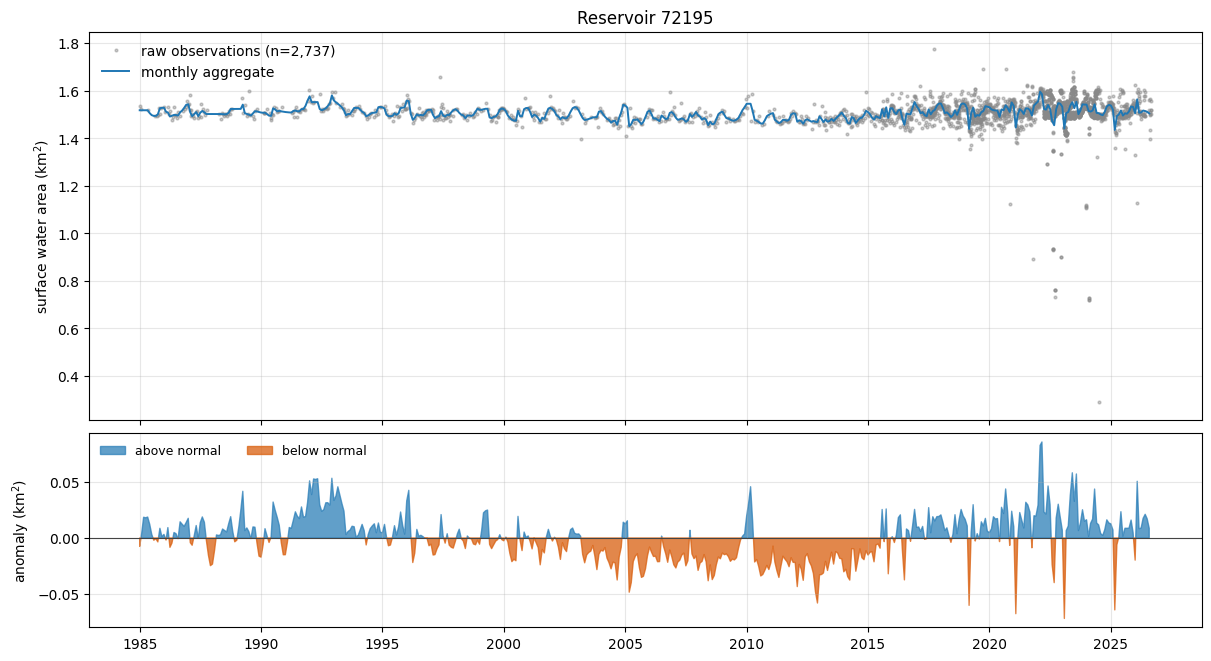

In [7]:
def area_unit(values_m2):
    """Pick m2 / ha / km2 based on the magnitude of the data.

    Returns (divisor, unit label).
    """
    typical = np.nanmedian(np.abs(values_m2))
    if typical >= 1e6:
        return 1e6, "km$^2$"
    if typical >= 1e4:
        return 1e4, "ha"
    return 1.0, "m$^2$"


scale, unit = area_unit(monthly.values)
label = f"surface water area ({unit})"

# The climatology spans the WHOLE record: each of the 12 values is the mean of
# every January, every February and so on that this reservoir has, from 1985 to
# the end of the series. Nothing is restricted to a reference period.
# reindex() then lines those 12 values up with the ~500 timestamps.
climatology = monthly.groupby(monthly.index.month).mean()
anomaly = monthly - climatology.reindex(monthly.index.month).values

per_month = monthly.groupby(monthly.index.month).size()
print(f"climatology baseline: {monthly.index[0]:%Y-%m} to {monthly.index[-1]:%Y-%m}, "
      f"{len(monthly)} months")
print(f"  years averaged per calendar month: {per_month.min()}-{per_month.max()}")

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(12, 6.5), sharex=True,
    height_ratios=[2, 1], layout="constrained",
)

ax.plot(raw.index, raw.values / scale, ".", ms=4, alpha=0.45, color="#888888",
        label=f"raw observations (n={len(raw):,})")
ax.plot(monthly.index, monthly.values / scale, "-", lw=1.4, color="#1f77b4",
        label="monthly aggregate")

title = f"Reservoir {RESERVOIR_ID}"
if meta["name"]:
    title += f" — {meta['name']}"
ax.set_title(title)
ax.set_ylabel(label)
ax.grid(alpha=0.3)
ax.legend(frameon=False)

a = anomaly / scale
ax2.axhline(0, color="#444444", lw=0.8)
ax2.fill_between(a.index, 0, a.values, where=a.values >= 0,
                 color="#2c7fb8", alpha=0.75, interpolate=True, label="above normal")
ax2.fill_between(a.index, 0, a.values, where=a.values < 0,
                 color="#d95f0e", alpha=0.75, interpolate=True, label="below normal")
ax2.set_ylabel(f"anomaly ({unit})")
ax2.set_xlabel("")
ax2.grid(alpha=0.3)
ax2.legend(frameon=False, ncol=2, loc="upper left", fontsize=9)

The anomaly is the monthly series with the seasonal cycle removed.

In [8]:
# How much of the variability the seasonal cycle actually accounted for.
mean_area = monthly.mean()
print(f"mean area        : {mean_area / scale:,.3g} {unit.replace('$^2$', '2')}")
print(f"month-to-month sd: {monthly.std() / scale:,.3g}  "
      f"({monthly.std() / mean_area:.1%} of mean)")
print(f"anomaly sd       : {anomaly.std() / scale:,.3g}  "
      f"({anomaly.std() / mean_area:.1%} of mean)")
print(f"seasonal cycle explains {1 - anomaly.var() / monthly.var():.1%} of the variance")

print()
print("wettest months for the time of year:")
for t, v in anomaly.nlargest(3).items():
    print(f"  {t:%Y-%m}  {v / mean_area:+.1%}")
print("driest months for the time of year:")
for t, v in anomaly.nsmallest(3).items():
    print(f"  {t:%Y-%m}  {v / mean_area:+.1%}")

mean area        : 1.51 km2
month-to-month sd: 0.024  (1.6% of mean)
anomaly sd       : 0.0209  (1.4% of mean)
seasonal cycle explains 23.9% of the variance

wettest months for the time of year:
  2022-03  +5.7%
  2022-02  +5.5%
  2023-06  +3.9%
driest months for the time of year:
  2023-02  -4.8%
  2021-02  -4.5%
  2025-03  -4.3%


Observation density increases markedly from around 2015, when Sentinel-2 joined
Landsat. Apparent changes in variability across that boundary may reflect
sampling rather than the reservoir itself.

## Plot the outline

Outlines are archived as GeoJSON, stored as ragged UTF-8 bytes (see the helper below).

These outlines come from OpenStreetMap and HydroLAKES; OpenStreetMap data is
ODbL-licensed and requires attribution to "© OpenStreetMap contributors" if you
redistribute it. `source_name` says which dataset each reservoir came from.

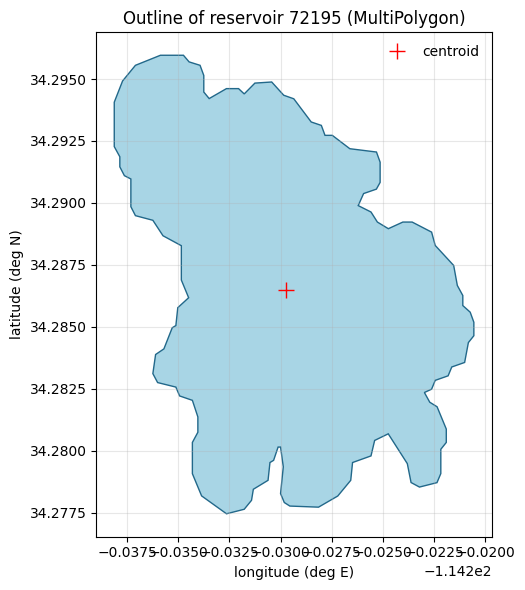

In [9]:
def reservoir_geometry(ds, reservoir_id):
    """The GeoJSON outline of one reservoir, as a dict.

    Outlines are stored the same ragged way as the observations: UTF-8 encoded
    and concatenated along `geometry_bytes`, with `geometry_row_size` giving
    each reservoir's byte count. They range from 271 bytes to 935 kB, and one
    string per reservoir would make xarray widen the variable to a fixed
    935,507 characters across all 71,208 rows -- a 248 GiB allocation.
    """
    ids = ds["reservoir"].values
    hits = np.flatnonzero(ids == int(reservoir_id))
    if hits.size == 0:
        raise KeyError(f"reservoir {reservoir_id} is not in this file")
    i = int(hits[0])

    row_size = ds["geometry_row_size"].values
    start = int(row_size[:i].sum())
    n = int(row_size[i])
    if n == 0:
        return None
    return json.loads(ds["geometry_utf8"][start:start + n].values.tobytes().decode("utf-8"))


geom = reservoir_geometry(ds, RESERVOIR_ID)
i = int(np.flatnonzero(ds["reservoir"].values == RESERVOIR_ID)[0])   # for the centroid

polygons = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]

fig, ax = plt.subplots(figsize=(6, 6))
for poly in polygons:
    for ring_no, ring in enumerate(poly):
        xy = np.asarray(ring)
        # ring 0 is the exterior; any further rings are holes
        ax.fill(xy[:, 0], xy[:, 1],
                facecolor="#a8d5e5" if ring_no == 0 else "white",
                edgecolor="#22688a", lw=1.0, zorder=ring_no)

ax.plot(ds["longitude"].values[i], ds["latitude"].values[i], "r+", ms=12, label="centroid")
ax.set_aspect(1 / np.cos(np.deg2rad(float(ds["latitude"].values[i]))))
ax.set_xlabel("longitude (deg E)")
ax.set_ylabel("latitude (deg N)")
ax.set_title(f"Outline of reservoir {RESERVOIR_ID} ({geom['type']})")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()

## The seasonal cycle itself

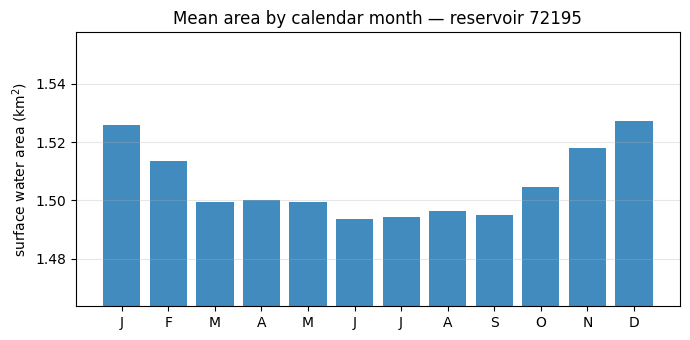

In [10]:
clim = climatology / scale          # the same baseline the anomaly used

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(clim.index, clim.values, color="#1f77b4", alpha=0.85)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_ylabel(label)
ax.set_title(f"Mean area by calendar month — reservoir {RESERVOIR_ID}")
ax.set_ylim(clim.min() * 0.98, clim.max() * 1.02)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()

## Export

Both series in one table, for use outside xarray.

In [11]:
both = pd.DataFrame({"monthly": monthly}).join(pd.DataFrame({"raw": raw}), how="outer")
both.index.name = "time"

both.to_csv(f"reservoir_{RESERVOIR_ID}.csv")
print(f"wrote reservoir_{RESERVOIR_ID}.csv  ({len(both)} rows)")
both.head()

wrote reservoir_72195.csv  (3230 rows)


,monthly,raw
time,,
1985-01-01 00:00:00,1518170.625,NaN
1985-01-03 17:40:00,NaN,1537021.000
1985-01-19 17:40:00,NaN,1523306.875
1985-02-01 00:00:00,1518170.625,NaN
1985-03-01 00:00:00,1518170.625,NaN


## A regional example — reservoirs across Iran

Two things this example is careful about:

1. **Only the monthly values are used.** `surface_water_area_monthly` is the
   filtered series, spikes from cloud, shadow and partial scenes have been
   removed. 
2. **Not every reservoir has a usable record**, even where the archive appears
   to hold one. Three separate checks below deal with that.

In [13]:
from matplotlib.path import Path as MplPath

# Iran, simplified from a full-resolution boundary. Lon/lat degrees, WGS84.
IRAN_OUTLINE = [
    [(44.61,39.779), (44.471,39.684), (44.425,39.413), (44.029,39.381),
     (44.212,39.136), (44.172,38.991), (44.312,38.807), (44.258,38.719),
     (44.306,38.393), (44.514,38.34), (44.221,37.886), (44.588,37.766),
     (44.584,37.443), (44.797,37.31), (44.749,37.111), (44.903,37.024),
     (44.835,36.797), (45.034,36.732), (45.01,36.528), (45.102,36.412),
     (45.272,36.388), (45.361,35.978), (45.545,35.997), (45.762,35.804),
     (46.088,35.858), (46.35,35.791), (46.012,35.686), (45.987,35.51),
     (46.156,35.286), (46.114,35.238), (46.185,35.225), (46.188,35.109),
     (46.062,35.04), (45.92,35.094), (45.865,34.895), (45.688,34.815),
     (45.656,34.722), (45.75,34.535), (45.533,34.599), (45.439,34.457),
     (45.584,34.304), (45.58,34.145), (45.412,33.981), (45.754,33.592),
     (45.904,33.637), (45.956,33.552), (45.869,33.492), (46.008,33.512),
     (46.188,33.265), (46.217,33.202), (46.044,33.095), (46.165,33.073),
     (46.111,32.974), (46.508,32.904), (47.175,32.458), (47.284,32.496),
     (47.461,32.397), (47.57,32.216), (47.53,32.141), (47.865,31.784),
     (47.683,31.395), (47.684,31), (48.031,30.996), (48.025,30.479),
     (48.404,30.216), (48.463,29.992), (48.683,29.912), (48.733,30.001),
     (48.914,29.999), (48.966,30.134), (48.91,30.296), (49.195,30.21),
     (49.156,30.112), (49.481,30.125), (49.552,29.986), (49.959,30.188),
     (50.087,30.148), (50.129,29.93), (50.64,29.406), (50.629,29.138),
     (50.728,29.049), (50.809,29.108), (50.865,28.809), (51.016,28.78),
     (51.111,28.417), (51.467,27.803), (51.452,27.916), (51.553,27.818),
     (52.041,27.82), (52.215,27.671), (52.44,27.618), (52.657,27.302),
     (53.451,26.956), (53.472,26.844), (53.719,26.688), (54.02,26.739),
     (54.312,26.69), (54.603,26.49), (54.796,26.48), (55.252,26.766),
     (55.511,26.765), (55.675,26.977), (56.139,27.119), (56.354,27.168),
     (56.747,27.093), (57.049,26.628), (57.052,26.316), (57.299,25.77),
     (57.711,25.729), (57.748,25.623), (57.95,25.679), (58.083,25.547),
     (58.87,25.519), (59.075,25.386), (59.439,25.448), (60.484,25.257),
     (60.451,25.378), (60.536,25.395), (60.585,25.268), (61.062,25.18),
     (61.403,25.006), (61.611,25.16), (61.673,25.652), (61.837,25.744),
     (61.894,25.888), (61.836,25.914), (61.891,26.249), (62.029,26.333),
     (62.216,26.27), (62.312,26.519), (62.759,26.643), (63.196,26.646),
     (63.251,27.096), (63.333,27.122), (63.278,27.218), (62.774,27.257),
     (62.847,27.463), (62.759,28.031), (62.793,28.282), (62.596,28.248),
     (62.398,28.428), (61.87,28.599), (61.529,28.979), (61.359,29.382),
     (60.873,29.859), (61.819,30.847), (61.847,31.021), (61.715,31.395),
     (60.839,31.5), (60.798,32.028), (60.855,32.237), (60.578,33.051),
     (60.847,33.485), (60.949,33.522), (60.52,33.659), (60.501,34.117),
     (60.674,34.311), (60.91,34.315), (60.71,34.53), (60.984,34.661),
     (61.138,35.094), (61.097,35.262), (61.196,35.307), (61.283,35.534),
     (61.254,35.813), (61.128,35.965), (61.227,36.129), (61.133,36.655),
     (60.342,36.633), (60.013,37.038), (59.502,37.195), (59.381,37.527),
     (59.244,37.51), (58.826,37.693), (58.255,37.675), (58.211,37.771),
     (57.755,37.923), (57.513,37.923), (57.354,38.018), (57.376,38.083),
     (57.2,38.277), (57.041,38.191), (56.475,38.268), (56.332,38.178),
     (56.332,38.083), (55.453,38.078), (54.871,37.771), (54.787,37.516),
     (54.681,37.436), (54.246,37.319), (53.869,37.356), (53.992,36.937),
     (53.113,36.862), (51.883,36.598), (50.977,36.822), (50.328,37.147),
     (50.224,37.401), (49.389,37.527), (49.092,37.666), (48.966,37.879),
     (48.896,38.441), (48.623,38.402), (48.458,38.623), (48.312,38.608),
     (48.241,38.739), (48.027,38.827), (48.021,38.897), (48.34,39.019),
     (48.139,39.258), (48.373,39.373), (48.035,39.695), (47.392,39.464),
     (47.06,39.198), (46.835,39.139), (46.534,38.868), (46.333,38.924),
     (46.16,38.841), (45.461,38.991), (44.964,39.421), (44.897,39.604),
     (44.61,39.779)],
]


def reservoirs_inside(ds, rings):
    """Ids of every reservoir whose centroid falls inside any of the rings."""
    lon, lat = ds["longitude"].values, ds["latitude"].values
    pts = np.column_stack([lon, lat])
    inside = np.zeros(len(pts), dtype=bool)
    for ring in rings:
        xy = np.asarray(ring)
        # a bounding-box prefilter keeps the polygon test to a few hundred points
        cand = (
            (lon >= xy[:, 0].min()) & (lon <= xy[:, 0].max())
            & (lat >= xy[:, 1].min()) & (lat <= xy[:, 1].max()) & ~inside
        )
        if cand.any():
            inside[cand] = MplPath(xy).contains_points(pts[cand])
    return ds["reservoir"].values[inside]


iran_ids = reservoirs_inside(ds, IRAN_OUTLINE)
iran = ds["surface_water_area_monthly"].sel(reservoir=iran_ids)   # monthly only

print(f"{len(iran_ids)} reservoirs inside the outline")
print(f"monthly block: {iran.shape} = {iran.nbytes / 1e6:.1f} MB")

186 reservoirs inside the outline
monthly block: (186, 500) = 0.4 MB


### Deciding which reservoirs can go in the average

Records here are not all the same length, and length is not the only thing that
varies:

**a. Enough years behind each climatology value.**  Require at least ten years for *every* calendar month.

**b. The reservoir has to have existed all along.**  Require the first decade's mean to be at least half the
long-term mean.

**c. Enough reservoirs behind each month.** Records end on different dates, so
the last few months are averages over a handful of reservoirs. Mask any month
where fewer than half of them report.

In [14]:
years = iran["time"].dt.year

# a. at least 10 years behind every one of the 12 climatology values
per_calendar_month = iran.notnull().groupby("time.month").sum("time")
enough_years = (per_calendar_month >= 10).all("month")

# b. already established at the start of the record, not built during it
first_decade = iran.sel(time=(years <= 1994)).mean("time")
established = (first_decade / iran.mean("time")) >= 0.5

keep = enough_years & established
kept = iran.sel(reservoir=iran["reservoir"][keep])

print(f"inside Iran                      : {iran.sizes['reservoir']}")
print(f"  a. usable climatology          : {int(enough_years.sum())}"
      f"   (dropped {int((~enough_years).sum())})")
print(f"  b. established by 1994         : {int(established.sum())}"
      f"   (dropped {int((~established).sum())} built during the record)")
print(f"  kept for the index             : {kept.sizes['reservoir']}")

inside Iran                      : 186
  a. usable climatology          : 183   (dropped 3)
  b. established by 1994         : 125   (dropped 61 built during the record)
  kept for the index             : 125


### Where they are

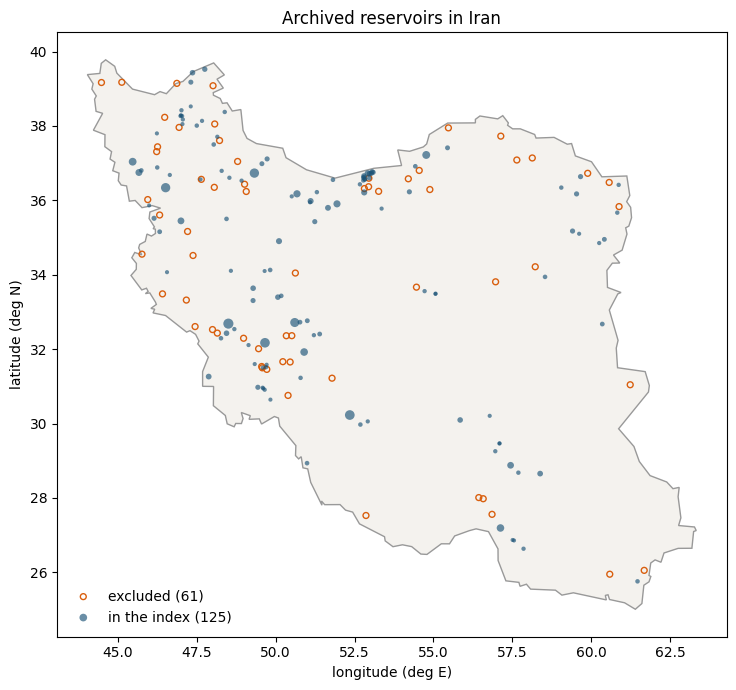

In [15]:
klon = ds["longitude"].sel(reservoir=kept["reservoir"]).values
klat = ds["latitude"].sel(reservoir=kept["reservoir"]).values
dropped = iran["reservoir"][~keep]
dlon = ds["longitude"].sel(reservoir=dropped).values
dlat = ds["latitude"].sel(reservoir=dropped).values

fig, ax = plt.subplots(figsize=(8, 7))
for ring in IRAN_OUTLINE:
    xy = np.asarray(ring)
    ax.fill(xy[:, 0], xy[:, 1], facecolor="#f4f2ee", edgecolor="#999999", lw=1.0, zorder=0)

areas_kept = kept.mean("time").values
ax.scatter(dlon, dlat, s=18, facecolor="none", edgecolor="#d95f0e", lw=1.0,
           zorder=2, label=f"excluded ({len(dlon)})")
ax.scatter(klon, klat, s=8 + 45 * np.sqrt(areas_kept / areas_kept.max()),
           c="#1a5276", alpha=0.65, edgecolors="none", zorder=3,
           label=f"in the index ({len(klon)})")

ax.set_aspect(1 / np.cos(np.deg2rad(32)))
ax.set_xlabel("longitude (deg E)")
ax.set_ylabel("latitude (deg N)")
ax.set_title("Archived reservoirs in Iran")
ax.legend(frameon=False, loc="lower left")
fig.tight_layout()

### The index

The anomaly is computed per reservoir first and only then averaged across
reservoirs.  Each anomaly is then divided by that reservoir's own mean area, so all of them
count equally despite spanning 0.002 to 50 km².

In [16]:
# Steps 1-3 are per reservoir; only step 4 combines them.
clim_ir = kept.groupby("time.month").mean("time")          # 1. own climatology
anom_ir = kept.groupby("time.month") - clim_ir             # 2. own anomaly
rel_ir = anom_ir / kept.mean("time")                       # 3. own mean area
index = (rel_ir.mean("reservoir") * 100).to_series()       # 4. average, last

# c. mask months that rest on too few reservoirs
n_contrib = rel_ir.notnull().sum("reservoir").to_series()
thin = n_contrib < 0.5 * kept.sizes["reservoir"]
print(f"masking {int(thin.sum())} months with under half the reservoirs reporting:")
for t in n_contrib.index[thin]:
    print(f"    {t:%Y-%m}: {int(n_contrib[t])} of {kept.sizes['reservoir']}")
index[thin] = np.nan

roll = index.rolling(12, center=True, min_periods=6).mean()
print()
print(f"index range {index.min():+.1f}% to {index.max():+.1f}% of normal")

masking 3 months with under half the reservoirs reporting:
    2026-06: 23 of 125
    2026-07: 23 of 125
    2026-08: 13 of 125

index range -29.2% to +23.4% of normal


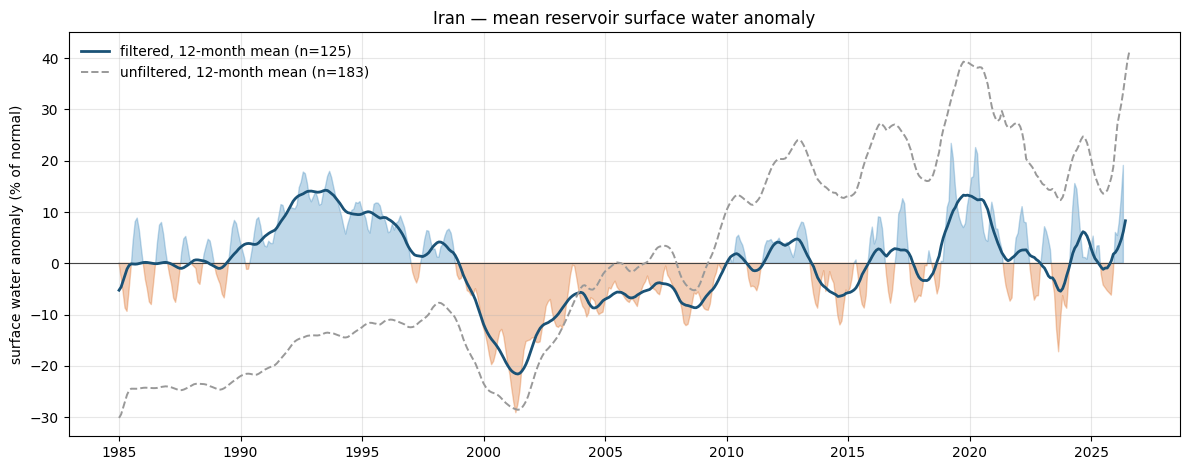

In [17]:
# the same index without filters b and c, to show what they were protecting against
raw_set = iran.sel(reservoir=iran["reservoir"][enough_years])
clim_raw = raw_set.groupby("time.month").mean("time")
rel_raw = (raw_set.groupby("time.month") - clim_raw) / raw_set.mean("time")
index_raw = (rel_raw.mean("reservoir") * 100).to_series()
roll_raw = index_raw.rolling(12, center=True, min_periods=6).mean()

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.axhline(0, color="#444444", lw=0.8)
ax.fill_between(index.index, 0, index.values, where=index.values >= 0,
                color="#2c7fb8", alpha=0.30, interpolate=True)
ax.fill_between(index.index, 0, index.values, where=index.values < 0,
                color="#d95f0e", alpha=0.30, interpolate=True)
ax.plot(roll.index, roll.values, color="#1a5276", lw=2.0,
        label=f"filtered, 12-month mean (n={kept.sizes['reservoir']})")
ax.plot(roll_raw.index, roll_raw.values, color="#999999", lw=1.4, ls="--",
        label=f"unfiltered, 12-month mean (n={raw_set.sizes['reservoir']})")

ax.set_ylabel("surface water anomaly (% of normal)")
ax.set_title("Iran — mean reservoir surface water anomaly")
ax.grid(alpha=0.3)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()

### What the two lines show

The **filtered** line is a hydrological record. It is flat over the long run with
no net trend across 40 years.

- **1999–2002**, the deepest sustained drought in the record, bottoming near
  −22% in mid-2001. This was Iran's most severe drought in decades.
- **2007–2009** and **2014–2015**, drier again.
- **1992–1995** and **2019–2020** clearly wet; spring 2019 brought severe
  flooding across much of Iran.



In [18]:
ds.close()